In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_core.tools import tool


# tool 구성에는 세가지 구성이 필요하다
# 1. decorater (@tool)
# 2. description ("해당 툴의 설명")
# 3. expected arg ("인자")
@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a+b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a*b


In [5]:
add.invoke({"a": 1, "b": 2})

3

In [6]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]
llm_with_tools = small_llm.bind_tools([add, multiply])
tool_node = ToolNode(tools=tool_list)



In [7]:
add.invoke({"a": 1, "b": 2})
multiply.invoke({"a": 1, "b": 2})

2

In [8]:
ai_message = llm_with_tools.invoke("1과 2를 더하고 곱해서 출력하세요")

In [9]:
# tool_node는 "messages" 키를 가지는 딕셔너리를 인자로 받음
# 마지막이 ai_message이고 ai_message에는 tool_calls가 있어야 한다.
tool_node.invoke({"messages": [ai_message]})

{'messages': [ToolMessage(content='3', name='add', tool_call_id='call_trAsNLbJgZ4V5w4mjUcFicbY'),
  ToolMessage(content='2', name='multiply', tool_call_id='call_MiVmyXWNaQjpy6IY1OoDcLFo')]}

In [11]:
from langgraph.graph import MessagesState, StateGraph
# 내장 state 사용
graph_builder = StateGraph(MessagesState)

In [12]:
# HumanMessage -> AIMessage -> ToolMessage ----> Messages 모두 추가
# 노드 선언

# llm_with_tools에 invoke만 하는 agent 노드
def agent(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


In [13]:
# agent <-> tool_node 간 답변을 얻을떄 까지 메시지를 계속 교환 후 답변이 완료되면 end로 가야함
# 정보가 더 필요한지, 답변이 완료되었는지를 판단하기 위한 conditional 이 필요함

def should_continue(state: MessagesState):
    messages = state["messages"]
    messages[-1].tool_calls
    # 마지막 메시지가 tool_calls가 있는지 확인
    # 있으면 True, 없으면 False
    if len(messages[-1].tool_calls) > 0:
        return 'tools'
    return 'end'

In [14]:
# 노드 추가
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)

# shoud_continue는 conditional edge에서 분간하기 떄문에 노드로는 추가하지 않음 

In [15]:
# 그래프 구성
from langgraph.graph import START, END

graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        'tools': "tools",
        'end': END
    }
)
graph_builder.add_edge("tools", "agent")



In [17]:
graph = graph_builder.compile()

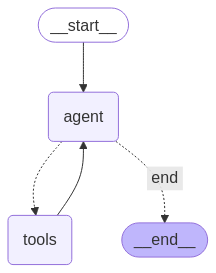

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
from langchain_core.messages import HumanMessage

# stream 모드로 실행해 agent가 어떤식으로 동작하는지 확인
for chunk in graph.stream({'messages': [HumanMessage('1에 2를 더하고 3을 곱하면?')]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

1에 2를 더하고 3을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (call_oQ1KHiARij6oUrklp91wICId)
 Call ID: call_oQ1KHiARij6oUrklp91wICId
  Args:
    a: 1
    b: 2
  multiply (call_zkxQVO5hOqcxWEfOPBeCuLgy)
 Call ID: call_zkxQVO5hOqcxWEfOPBeCuLgy
  Args:
    a: 3
    b: 2
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

1에 2를 더하면 3이 되고, 그 결과에 3을 곱하면 6이 됩니다.
